In [4]:
import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.integrate import solve_ivp
import pandas as pd

from rebinding.efflux_model_collection import washout_vary_bound
from rebinding.fig_utils import defaultStyle, save_fig
defaultStyle(fs=14)

# Data

In [6]:
xmax = 200
ymax = 10
n_ad = 9

def load_nc_data(path, n_ad, xmax=200, ymax=10):
    data = pd.read_csv(path, header=None).values
    nc_data = data[:-n_ad, :]
    nc_data[:, 0] *= xmax
    nc_data[:, 1] *= ymax
    ad_time = data[-n_ad:, 0] * xmax
    return nc_data, ad_time


data_1 = load_nc_data("../data/Friberg_2003/Friberg_fig5-1.csv", 9)
data_2 = load_nc_data("../data/Friberg_2003/Friberg_fig5-2.csv", 11)
data_3 = load_nc_data("../data/Friberg_2003/Friberg_fig5-3.csv", 9)

# PK

In [7]:
circ_0 = data_2[0][0, 1]
mtt = 127
ktr = 4 / mtt
gamma = 0.23
slope = 2.21


def time_post_infusion(t, ad_times):
    last_ad = ad_times[np.where((ad_times * 24) <= t)[0][-1]]
    t -= last_ad * 24
    return t

def plasma_conc(t, ad_times, c0, tau):
    t = time_post_infusion(t, ad_times)
    return c0 * np.exp(-(t / tau))
    

def blood_cell_dynamics(t, y, ktr, gamma, slope, pk):
    prol, tr1, tr2, tr3, circ = y
    E_drug = pk(t) * slope
    dprol = ktr * prol * (1 - E_drug) * (circ_0 / circ) ** gamma - ktr * prol
    dtr1 = ktr * (1 - E_drug) * prol - ktr * tr1
    dtr2 = ktr * (tr1 - tr2)
    dtr3 = ktr * (tr2 - tr3)
    dcirc = ktr * (tr3 - circ)
    return [dprol, dtr1, dtr2, dtr3, dcirc]


def blood_cell_dynamics_stepfn(t, y, ktr, gamma, duration, ad_times):
    prol, tr1, tr2, tr3, circ = y
    E_drug = time_post_infusion(t, ad_times) < (duration * 24)
    ktr_prol = ktr * (1 - E_drug)
    dprol = ktr_prol * prol * (circ_0 / circ) ** gamma - ktr * prol
    dtr1 = ktr * prol - ktr * tr1
    dtr2 = ktr * (tr1 - tr2)
    dtr3 = ktr * (tr2 - tr3)
    dcirc = ktr * (tr3 - circ)
    return [dprol, dtr1, dtr2, dtr3, dcirc]


pk = lambda t: plasma_conc(t, data_2[1], 4, 10)
sol_true = solve_ivp(
    blood_cell_dynamics,
    t_span=[0, 24 * 250],
    y0=[circ_0] * 5,
    args=[ktr, gamma, slope, pk],
    max_step=0.1,
)


In [8]:
from tqdm import tqdm

d_to_sols = {}
for d in tqdm([9 / 24, 3.5, 7]):
    sols = []
    for i, data in enumerate([data_1, data_2, data_3]):
        circ0 = data[0][0, 1] # if i < 2 else 5
        sol = solve_ivp(
            blood_cell_dynamics_stepfn,
            t_span=[0, 24 * 250],
            y0=[circ0] * 5,
            args=[ktr, gamma, d, data[1]],
            max_step=0.1,
            dense_output=True
        )
        t_eval = data[0][:, 0] * 24
#        err.append(((sol.sol(t_eval)[-1] - data[0][:, 1]) ** 2).sum())
        sols.append(sol)
    d_to_sols[d] = sols

100%|██████████████████████████████████████████████| 3/3 [00:42<00:00, 14.10s/it]


Saving figure fig6-patients-anc


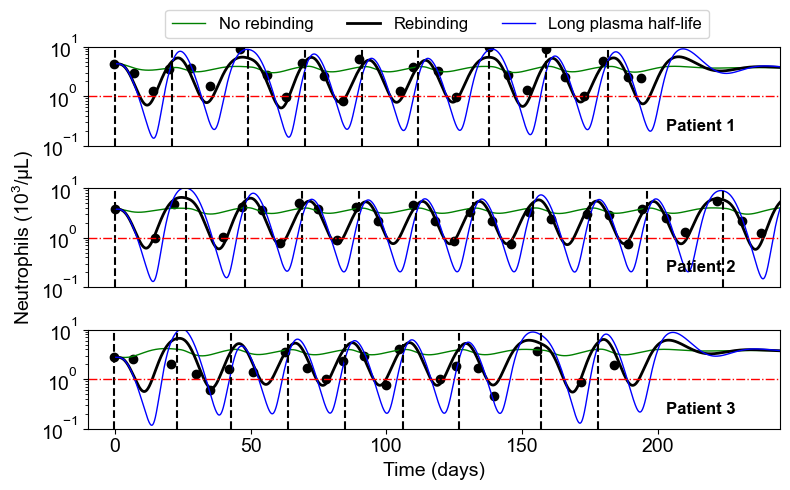

In [9]:
_, ax = plt.subplots(3, 1, figsize=(8, 5))
labels = [
    "No rebinding",
    "Rebinding",
    "Long plasma half-life",
]
for i, data in enumerate([data_1, data_2, data_3]):
    
    ax[i].scatter(data[0][:, 0], data[0][:, 1], color="k")
    
    for j, d in enumerate([9 / 24, 3.5, 7]):
        sol = d_to_sols[d][i]
        lw = [1, 2, 1][j]
        ax[i].plot(sol.t / 24, sol.y[-1], color=["green", "k", "blue"][j], lw=lw, label=labels[j])
    
    # ax[i].set_ylim([-1, 11])
    ax[i].set_xlim([-10, 245])
    ax[i].set_ylim([0.1, 10])
    
    for t in data[1]:
        ax[i].axvline(t, ls='--', color='k')
    if i < 2:
        ax[i].tick_params(
            axis="x",
            which="both",
            bottom=False,
            top=False,
            labelbottom=False,
        )
    ax[i].axhline(1, color="r", lw=1, ls="-.")
    ax[i].text(203, 0.2, f"Patient {i + 1}", fontsize=12, fontweight="bold")
    ax[i].set_yscale("log")
ax[0].legend(bbox_to_anchor=(0.1, 1), fontsize=12, ncols=3, title_fontsize=12)
ax[1].set_ylabel("Neutrophils " + "($10^3$/μL)")
ax[2].set_xlabel("Time (days)")
save_fig("fig6-patients-anc", fmt="png", dpi=300)

In [10]:
sols = []
data = data_2
circ0 = data[0][0, 1] # if i < 2 else 5

sol_high_3w = solve_ivp(
    blood_cell_dynamics_stepfn,
    t_span=[0, 24 * 250],
    y0=[circ0] * 5,
    args=[ktr, gamma, 3, np.arange(0, 250, 21)],
    max_step=0.1,
    dense_output=True
)
sol_high_1w = solve_ivp(
    blood_cell_dynamics_stepfn,
    t_span=[0, 24 * 250],
    y0=[circ0] * 5,
    args=[ktr, gamma, 3, np.arange(0, 250, 7)],
    max_step=0.1,
    dense_output=True
)
sol_low_3w = solve_ivp(
    blood_cell_dynamics_stepfn,
    t_span=[0, 24 * 250],
    y0=[circ0] * 5,
    args=[ktr, gamma, 1.5, np.arange(0, 250, 21)],
    max_step=0.1,
    dense_output=True
)
sol_low_1w = solve_ivp(
    blood_cell_dynamics_stepfn,
    t_span=[0, 24 * 250],
    y0=[circ0] * 5,
    args=[ktr, gamma, 1.5, np.arange(0, 250, 7)],
    max_step=0.1,
    dense_output=True
)
sol_low_3d = solve_ivp(
    blood_cell_dynamics_stepfn,
    t_span=[0, 24 * 250],
    y0=[circ0] * 5,
    args=[ktr, gamma, 1.5, np.arange(0, 250, 3)],
    max_step=0.1,
    dense_output=True
)

Saving figure fig5-dosing_schedule


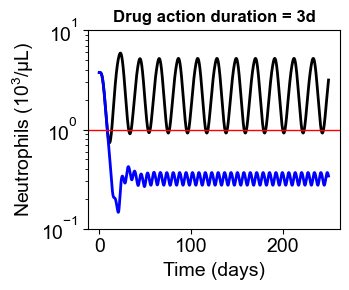

In [11]:
_, ax = plt.subplots(figsize=(3.6, 3))
plt.subplots_adjust(hspace=0.02)
ax.plot(sol_high_3w.t / 24, sol_high_3w.y[-1], color="k", lw=2)
ax.plot(sol_high_1w.t / 24, sol_high_1w.y[-1], color="b", lw=2)
ax.set_title("Drug action duration = 3d", fontsize=12, fontweight="bold")
ax.set_ylabel("Neutrophils " + "($10^3$/μL)")
ax.set_yscale("log")
ax.set_ylim([1e-1, 10])
ax.axhline(1, color="r", lw=1)
ax.set_xlabel("Time (days)")
save_fig("fig5-dosing_schedule", fmt="png", dpi=300)

Saving figure fig6-dosing-schedule


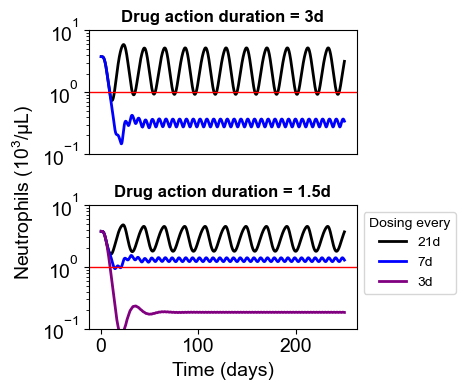

In [12]:
_, ax = plt.subplots(2, 1, figsize=(5, 4))
plt.subplots_adjust(hspace=0.02)
ax[0].plot(sol_high_3w.t / 24, sol_high_3w.y[-1], color="k", lw=2)
ax[0].plot(sol_high_1w.t / 24, sol_high_1w.y[-1], color="b", lw=2)
ax[0].set_title("Drug action duration = 3d", fontsize=12, fontweight="bold")
ax[0].tick_params(
    axis="x",
    bottom=False,
    labelbottom=False,
)

ax[1].plot(sol_low_3w.t / 24, sol_low_3w.y[-1], color="k", lw=2, label="21d")
ax[1].plot(sol_low_1w.t / 24, sol_low_1w.y[-1], color="b", lw=2, label="7d")
ax[1].plot(sol_low_3d.t / 24, sol_low_3d.y[-1], color="purple", lw=2, label="3d")
ax[1].set_title("Drug action duration = 1.5d", fontsize=12, fontweight="bold")
ax[1].legend(bbox_to_anchor=(1, 1), fontsize=10, title="Dosing every", title_fontsize=10, frameon=True)
# ax[1].legend(loc="lower right", fontsize=12, title="Dosing schedule", title_fontsize=12, frameon=True)
ax[1].set_ylabel("Neutrophils " + "($10^3$/μL)")
ax[1].yaxis.set_label_coords(-0.2,1.1)
ax[1].set_xlabel("Time (days)")

for bx in ax:
    bx.set_yscale("log")
    bx.set_ylim([1e-1, 10])
    bx.axhline(1, color="r", lw=1)
save_fig("fig6-dosing-schedule", fmt="png", dpi=300)